# RMSX — Google Colab Notebook

**RMSX** combines RMSD and RMSF into a single metric that maps protein motion in both time and space across molecular dynamics (MD) trajectories.

**Reference:** Beruldsen et al., *Sci Rep* (2026). [GitHub](https://github.com/AntunesLab/rmsx)

---
### Workflow
1. Install dependencies
2. Mount Google Drive and navigate to your folder
3. Set your input files and parameters
4. Run RMSX → publication-ready heatmaps



### This notebook was developed by Omar Arias-Gaguancela, PhD


### Follow me on LinkedIn for more content like this: https://www.linkedin.com/in/omarariasgaguancela/


## 1. Install Dependencies
> Run once per session.

In [ ]:
# ── Python packages ───────────────────────────────────────────────────────────
!pip install -q git+https://github.com/AntunesLab/rmsx.git

# ── R & required R packages (for publication plots) ───────────────────────────
!apt-get install -qq r-base > /dev/null 2>&1
!Rscript -e "options(device='png'); install.packages(c('ggplot2','reshape2','viridis','RColorBrewer','cowplot','scales'), repos='https://cran.r-project.org', quiet=TRUE)" 2>&1 | tail -5

# ── Verify ────────────────────────────────────────────────────────────────────
import importlib, subprocess
for pkg in ['rmsx', 'MDAnalysis', 'numpy', 'pandas', 'scipy']:
    spec = importlib.util.find_spec(pkg)
    print(f"{'\u2713' if spec else '\u2717 MISSING'}  {pkg}")

r = subprocess.run(['Rscript', '--version'], capture_output=True, text=True)
print(f"{'\u2713' if r.returncode == 0 else '\u2717 MISSING'}  R")

print("\nAll checks passed \u2014 ready to run RMSX.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓  rmsx
✓  MDAnalysis
✓  numpy
✓  pandas
✓  scipy
✓  R

All checks passed — ready to run RMSX.


## 2. Mount Google Drive & Set Working Directory

Mount your Drive, search for the folder that contains your **topology** (PDB/GRO) and **trajectory** (DCD/XTC) files, and set it as the working directory.

> **Tip:** Use `/` to navigate into sub-folders, e.g. `Projects/MD_runs/ubiquitin`

In [ ]:
#@title ##**Mounts drive and changes the directory to the folder previously created**
from google.colab import drive
import os
from IPython.display import display
import ipywidgets as widgets

drive.mount('/content/drive')

instruction_label = widgets.HTML(
    value="<b>Tip:</b> To search for folders within folders, use <code>/</code> to separate them. "
          "For example: <code>Folder1/Subfolder1</code>"
)

folder_input = widgets.Text(
    value='',
    placeholder='Enter part of the folder name (e.g., Folder/Subfolder)',
    description='Search:',
    layout=widgets.Layout(width='50%')
)

button_style  = {'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}
button_layout = widgets.Layout(width='auto', height='40px')

search_button = widgets.Button(
    description='Search',
    style=button_style,
    layout=button_layout
)

search_message_output = widgets.Output()

folder_dropdown = widgets.Dropdown(
    options=[],
    description='Select:',
    layout=widgets.Layout(width='50%')
)

confirm_button = widgets.Button(
    description='Set Directory',
    style=button_style,
    layout=button_layout
)

dir_output = widgets.Output()

def search_folders(b):
    base_path   = '/content/drive/MyDrive'
    matches     = []
    search_term = folder_input.value.lower()
    with search_message_output:
        search_message_output.clear_output()
        print("Searching for folders... Please be patient, this may take up to 30 seconds.")
    if search_term:
        for root, dirs, files in os.walk(base_path):
            for d in dirs:
                full_path     = os.path.join(root, d)
                relative_path = os.path.relpath(full_path, base_path)
                if search_term in relative_path.lower():
                    matches.append(full_path)
        folder_dropdown.options = matches if matches else ['No matches found']

def set_directory(b):
    selected_path = folder_dropdown.value
    if selected_path and selected_path != 'No matches found':
        os.chdir(selected_path)
        with dir_output:
            dir_output.clear_output()
            print(f"Current directory: {os.getcwd()}")
            print("Files found:")
            for f in sorted(os.listdir()):
                print(f"  {f}")

search_button.on_click(search_folders)
confirm_button.on_click(set_directory)

display(
    instruction_label,
    folder_input,
    search_button,
    search_message_output,
    folder_dropdown,
    confirm_button,
    dir_output
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


HTML(value='<b>Tip:</b> To search for folders within folders, use <code>/</code> to separate them. For example…

Text(value='', description='Search:', layout=Layout(width='50%'), placeholder='Enter part of the folder name (…

Button(description='Search', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color='#4CAF…

Output()

Dropdown(description='Select:', layout=Layout(width='50%'), options=(), value=None)

Button(description='Set Directory', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color…

Output()

## 3. Set Input Files & Parameters

Edit the variables below to match the file names in your folder and your analysis preferences.

In [ ]:
import os, pathlib

# ══════════════════════════════════════════════════════════════════════════════
# INPUT FILES  (file names relative to the folder you set above)
# ══════════════════════════════════════════════════════════════════════════════
TOPOLOGY_FILE   = None
TRAJECTORY_FILE = None

WORK_DIR = pathlib.Path(os.getcwd())

# Auto-detect topology file
topology_files = list(WORK_DIR.glob('*.pdb')) + list(WORK_DIR.glob('*.gro'))
if topology_files:
    TOPOLOGY_FILE = topology_files[0].name
    print(f"Detected topology file: {TOPOLOGY_FILE}")
else:
    print("No .pdb or .gro topology file detected. Please ensure your topology file is in the working directory.")

# Auto-detect trajectory file
trajectory_files = list(WORK_DIR.glob('*.dcd')) + list(WORK_DIR.glob('*.xtc'))
if trajectory_files:
    TRAJECTORY_FILE = trajectory_files[0].name
    print(f"Detected trajectory file: {TRAJECTORY_FILE}")
else:
    print("No .dcd or .xtc trajectory file detected. Please ensure your trajectory file is in the working directory.")


# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════
NUM_SLICES  = 9        # number of time windows for the heatmap
PALETTE     = 'mako'   # colour scheme: mako | turbo | viridis | magma | rocket
INTERPOLATE = True     # smooth the heatmap
TRIPLE      = True     # produce RMSX + RMSD + RMSF triple-panel figure
CHAIN_SEL   = None     # target a specific chain: None = auto, or e.g. 'A'
START_FRAME = 0        # first frame to analyse (None = beginning)
END_FRAME   = None     # last frame to analyse  (None = end)

# ══════════════════════════════════════════════════════════════════════════════
# MULTI-CHAIN (set True if your system has more than one chain)
# ══════════════════════════════════════════════════════════════════════════════
MULTI_CHAIN      = False  # set True to run all_chain_rmsx() instead
SYNC_COLOR_SCALE = True   # unified colour range across chains (multi-chain only)

# ══════════════════════════════════════════════════════════════════════════════
# FLIPBOOK
# ══════════════════════════════════════════════════════════════════════════════
SPACING_FACTOR = '0.6'  # model spacing in the multi-model PDB

# ── Resolve paths — ALL outputs go directly into WORK_DIR (no subfolders) ────
TOP_PATH  = WORK_DIR / TOPOLOGY_FILE if TOPOLOGY_FILE else None
TRAJ_PATH = WORK_DIR / TRAJECTORY_FILE if TRAJECTORY_FILE else None
OUT_DIR   = WORK_DIR   # RMSX results written directly here
OUT_FLIP  = WORK_DIR   # Flipbook PDBs written directly here

# ── Verify files exist ────────────────────────────────────────────────────────
ok = True
if TOP_PATH and TRAJ_PATH:
    for label, path in [('Topology', TOP_PATH), ('Trajectory', TRAJ_PATH)]:
        exists = path.exists()
        print(f"{'✓' if exists else '✗ NOT FOUND'}  {label}: {path.name}")
        if not exists:
            ok = False
    if ok:
        print("\nReady. Proceed to the next cell.")
    else:
        print("\nCheck that topology and trajectory files exist in your working directory.")
elif not TOP_PATH and not TRAJ_PATH:
    print("\nNo topology or trajectory files were automatically detected.")
elif not TOP_PATH:
    print("\nNo topology file was automatically detected.")
elif not TRAJ_PATH:
    print("\nNo trajectory file was automatically detected.")


Detected topology file: prot_lig_prod_1.pdb
Detected trajectory file: prot_lig_prod_1.dcd
✓  Topology: prot_lig_prod_1.pdb
✓  Trajectory: prot_lig_prod_1.dcd

Ready. Proceed to the next cell.


## 4. Imports & Helper

In [ ]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib

from rmsx import run_rmsx, all_chain_rmsx, run_rmsx_flipbook

# ── Publication-quality matplotlib defaults ───────────────────────────────────
matplotlib.rcParams.update({
    'font.family'   : 'sans-serif',
    'font.size'     : 11,
    'axes.titlesize': 12,
    'figure.dpi'    : 300,
    'savefig.dpi'   : 300,
})

def show_results(directory, title='Results'):
    """Display all PNG images in a directory inline."""
    pngs = [p for p in sorted(pathlib.Path(directory).rglob('*.png'))
            if '_display' not in p.name]
    if not pngs:
        print(f"No PNG files found in {directory}")
        return
    print(f"\n{'='*60}\n {title}  ({len(pngs)} image{'s' if len(pngs)!=1 else ''})\n{'='*60}")
    for png in pngs:
        print(f"\n\u25b6 {png.name}")
        img = mpimg.imread(str(png))
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(png.stem.replace('_', ' '), fontsize=12, pad=8)
        plt.tight_layout()
        plt.show()

print("Imports complete.")

Imports complete.


## 5. Run RMSX Analysis

Runs either **single-chain** or **multi-chain** RMSX depending on the `MULTI_CHAIN` flag set in Section 3.

Running single-chain RMSX...
Python Executable: /usr/bin/python3
Current Working Directory: /content/drive/MyDrive/RMSX_test


/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/PDBParser.py:309: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "


Available chains and their lengths (in residues):
Chain A: 10000 residues
Please enter the chain ID you would like to analyze from the following options:
A (10000 residues)
Chain ID: A
The directory '/content/drive/MyDrive/RMSX_test/chain_A_rmsx' is ready for use.


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Starting analysis...
Using the slicing method with num_slices=9
Truncating 1 excess frame(s). Original size: 100, Updated: 99
Processing frames 0 to 98 of the trajectory.
Number of slices: 9
First frame of slice 1 written to /content/drive/MyDrive/RMSX_test/chain_A_rmsx/slice_1_first_frame.pdb
Slice 1: RMSF computed for frames 0 to 10 (11 frames)
First frame of slice 2 written to /content/drive/MyDrive/RMSX_test/chain_A_rmsx/slice_2_first_frame.pdb
Slice 2: RMSF computed for frames 11 to 21 (11 frames)
First frame of slice 3 written to /content/drive/MyDrive/RMSX_test/chain_A_rmsx/slice_3_first_frame.pdb
Slice 3: RMSF computed for frames 22 to 32 (11 frames)
First frame of slice 4 written to /content/drive/MyDrive/RMSX_test/chain_A_rmsx/slice_4_first_frame.pdb
Slice 4: RMSF computed for frames 33 to 43 (11 frames)
First frame of slice 5 written to /content/drive/MyDrive/RMSX_test/chain_A_rmsx/slice_5_first_frame.pdb
Slice 5: RMSF computed for frames 44 to 54 (11 frames)
First frame of 

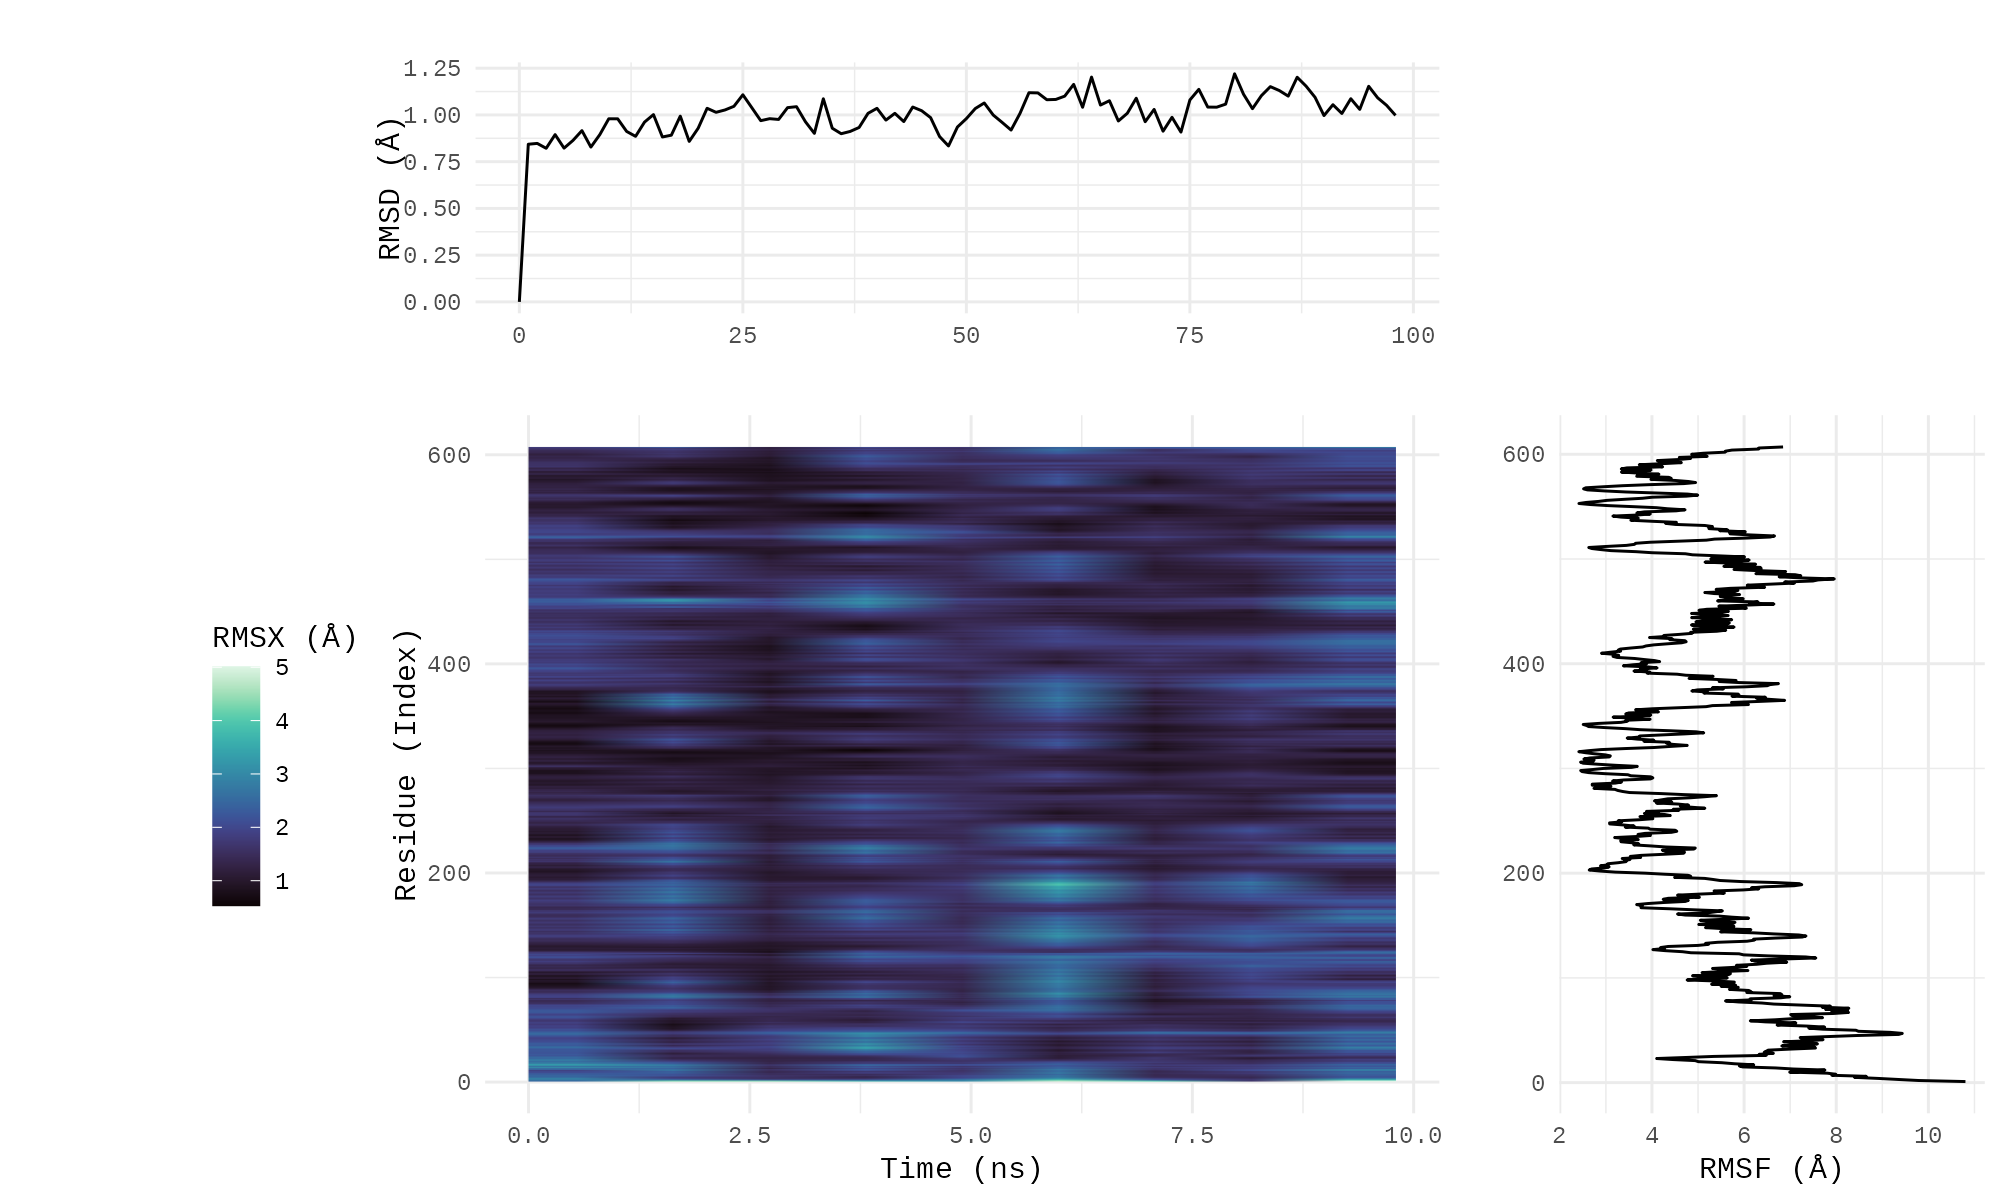


Now summarizing the top 3 and bottom 3 RMSX values...

===== Top 3 RMSX values across all slices =====
TimeSlice: slice_9.dcd, ChainID: A, ResidueID: 1, RMSX: 5.012
TimeSlice: slice_6.dcd, ChainID: A, ResidueID: 1, RMSX: 4.689
TimeSlice: slice_3.dcd, ChainID: A, ResidueID: 1, RMSX: 4.290

===== Bottom 3 RMSX values across all slices =====
TimeSlice: slice_4.dcd, ChainID: A, ResidueID: 544, RMSX: 0.529
TimeSlice: slice_4.dcd, ChainID: A, ResidueID: 551, RMSX: 0.562
TimeSlice: slice_4.dcd, ChainID: A, ResidueID: 317, RMSX: 0.587


✓ RMSX analysis complete.
Removed: /content/drive/MyDrive/RMSX_test/Rplots.pdf


In [ ]:
rmsx_kwargs = dict(
    topology_file   = str(TOP_PATH),
    trajectory_file = str(TRAJ_PATH),
    output_dir      = str(OUT_DIR),
    num_slices      = NUM_SLICES,
    palette         = PALETTE,
    interpolate     = INTERPOLATE,
    triple          = TRIPLE,
    chain_sele      = CHAIN_SEL,
    start_frame     = START_FRAME,
    end_frame       = END_FRAME,
    overwrite       = True,
    verbose         = True,
)

if MULTI_CHAIN:
    print("Running multi-chain RMSX...")
    all_chain_rmsx(**{**rmsx_kwargs, 'sync_color_scale': SYNC_COLOR_SCALE})
else:
    print("Running single-chain RMSX...")
    run_rmsx(**rmsx_kwargs)

print("\n\u2713 RMSX analysis complete.")

import glob
for f in glob.glob(str(WORK_DIR / 'Rplots.pdf')) + glob.glob('/content/Rplots.pdf'):
    pathlib.Path(f).unlink(missing_ok=True)
    print(f"Removed: {f}")


 RMSX Results  (1 image)

▶ rmsx_prot_lig_prod_1_9.800_ns_rmsx_plot_chain_A.png


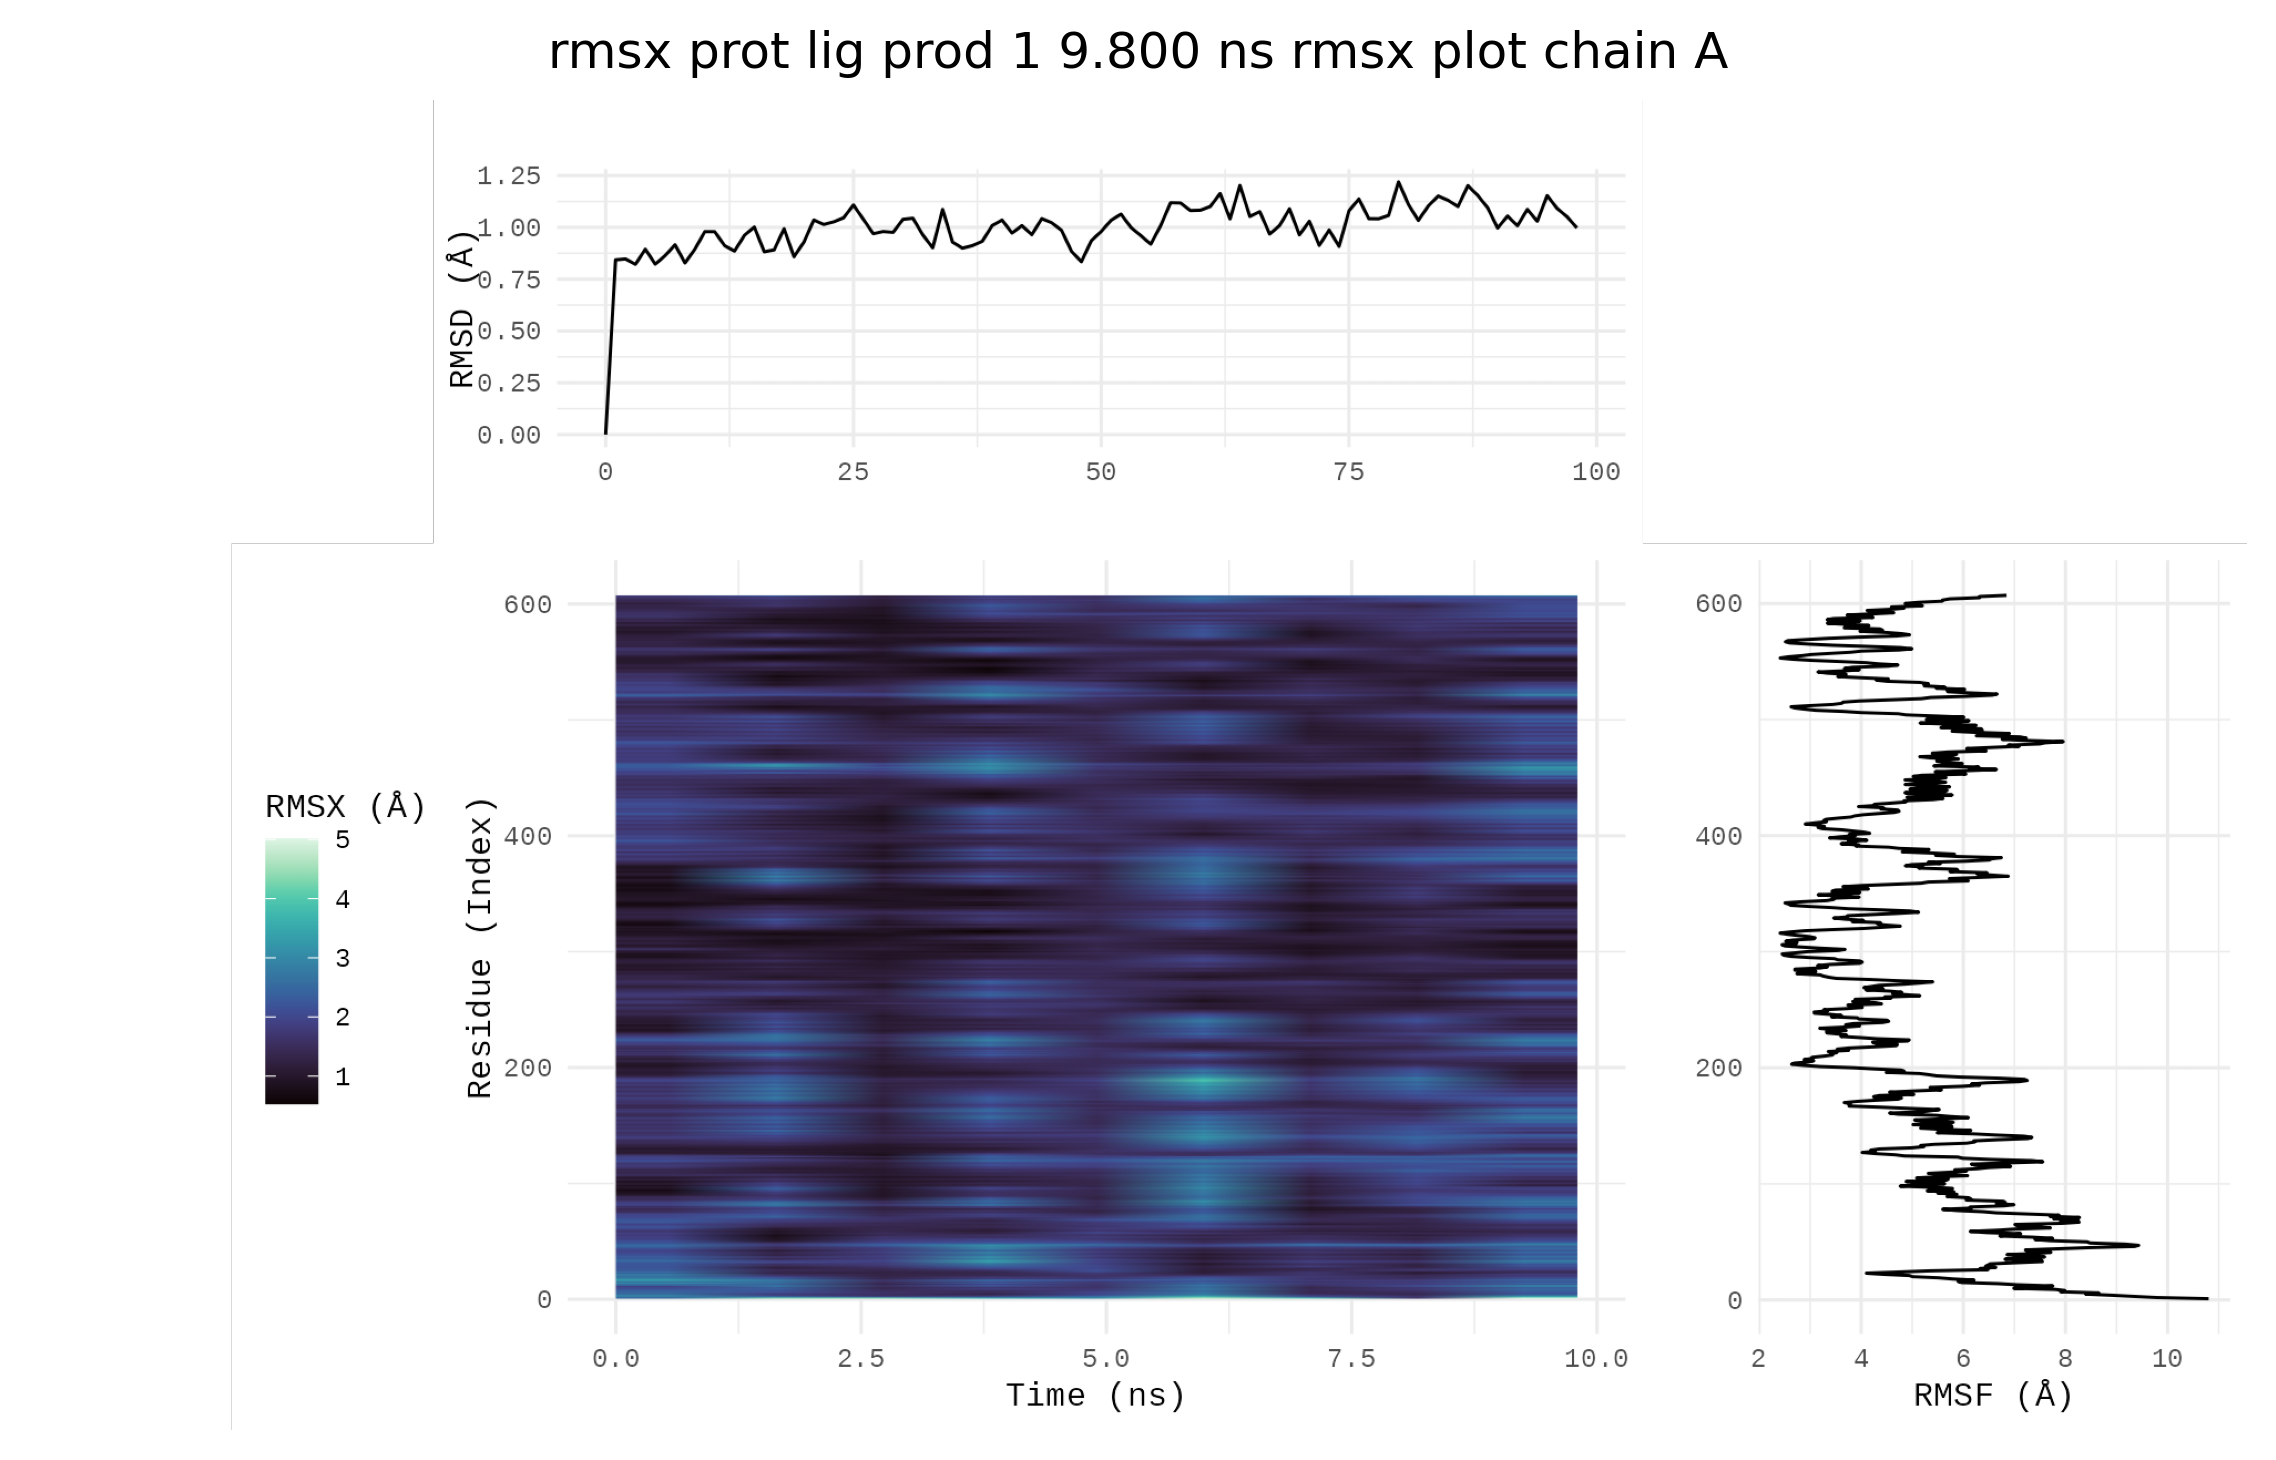


Reading RMSX data from: chain_A_rmsx/rmsx_prot_lig_prod_1_9.800_ns.csv

  TOP 15 MOST FLUCTUATING RESIDUES
  Rank  ResID    Chain    Mean RMSX   Max RMSX  Peak Time Window
  -------------------------------------------------------
  1     1        A           3.6491     5.0116  slice_9.dcd
  2     2        A           2.7335     4.0158  slice_6.dcd
  3     47       A           2.4756     3.0622  slice_4.dcd
  4     46       A           2.3286     3.1271  slice_4.dcd
  5     462      A           2.3162     3.2299  slice_4.dcd
  6     3        A           2.2788     3.2815  slice_6.dcd
  7     16       A           2.2646     3.1632  slice_1.dcd
  8     459      A           2.2541     3.2670  slice_9.dcd
  9     17       A           2.2142     3.2756  slice_1.dcd
  10    48       A           2.1834     2.7217  slice_9.dcd
  11    12       A           2.1808     2.8177  slice_9.dcd
  12    14       A           2.1746     2.9928  slice_1.dcd
  13    460      A           2.1641     3.2301  s

In [ ]:
import pandas as pd
import numpy as np
import os, pathlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

WORK_DIR    = pathlib.Path(os.getcwd())
RESULTS_DIR = WORK_DIR / 'chain_A_rmsx'

# ── 1. Display heatmap figures ────────────────────────────────────────────────
def show_results(directory, title='Results'):
    pngs = [p for p in sorted(pathlib.Path(directory).rglob('*.png'))
            if '_display' not in p.name]
    if not pngs:
        print(f"No PNG files found in {directory}")
        return
    print(f"\n{'='*60}\n {title}  ({len(pngs)} image{'s' if len(pngs)!=1 else ''})\n{'='*60}")
    for png in pngs:
        print(f"\n▶ {png.name}")
        img = mpimg.imread(str(png))
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(png.stem.replace('_', ' '), fontsize=12, pad=8)
        plt.tight_layout()
        plt.show()

show_results(RESULTS_DIR, title='RMSX Results')

# ── 2. Find the RMSX CSV ──────────────────────────────────────────────────────
csv_files = list(RESULTS_DIR.rglob('rmsx_*.csv'))

if not csv_files:
    print("\n⚠  No rmsx_*.csv found — skipping fluctuation report.")
else:
    csv_path = csv_files[0]
    print(f"\nReading RMSX data from: {csv_path.relative_to(WORK_DIR)}")

    df = pd.read_csv(csv_path)

    # Columns: ResidueID, ChainID, then one column per time slice
    skip_cols = ['ResidueID', 'ChainID']
    slice_cols = [c for c in df.columns if c not in skip_cols]

    df['mean_rmsx']  = df[slice_cols].mean(axis=1)
    df['max_rmsx']   = df[slice_cols].max(axis=1)
    df['peak_slice'] = df[slice_cols].idxmax(axis=1)

    TOP_N   = 15
    top_res = (df.nlargest(TOP_N, 'mean_rmsx')
                 [['ResidueID', 'ChainID', 'mean_rmsx', 'max_rmsx', 'peak_slice']]
                 .reset_index(drop=True))
    top_res.index += 1

    # ── Print report ──────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  TOP {TOP_N} MOST FLUCTUATING RESIDUES")
    print(f"{'='*62}")
    print(f"  {'Rank':<5} {'ResID':<8} {'Chain':<7} {'Mean RMSX':>10} {'Max RMSX':>10}  Peak Time Window")
    print(f"  {'-'*55}")
    for rank, row in top_res.iterrows():
        print(f"  {rank:<5} {int(row.ResidueID):<8} {row.ChainID:<7} "
              f"{row.mean_rmsx:>10.4f} {row.max_rmsx:>10.4f}  {row.peak_slice}")

    best = top_res.iloc[0]
    print(f"\n  ► Residue {int(best.ResidueID)} (chain {best.ChainID}) fluctuates the most")
    print(f"    Mean RMSX = {best.mean_rmsx:.4f} | Max RMSX = {best.max_rmsx:.4f}")
    print(f"    Highest motion at: {best.peak_slice}")
    print(f"{'='*62}\n")

    # ── Save Excel ────────────────────────────────────────────────────────────
    full_ranked = df.sort_values('mean_rmsx', ascending=False).reset_index(drop=True)
    full_ranked.index += 1

    excel_path = RESULTS_DIR / 'rmsx_fluctuation_report.xlsx'
    with pd.ExcelWriter(str(excel_path), engine='openpyxl') as writer:
        top_res.to_excel(writer, sheet_name=f'Top {TOP_N} Residues', index=True)
        full_ranked.to_excel(writer, sheet_name='All Residues Ranked', index=True)

    print(f"✓ Excel saved → chain_A_rmsx/rmsx_fluctuation_report.xlsx")
    print(f"   Sheet 1: Top {TOP_N} most fluctuating residues")
    print(f"   Sheet 2: All residues ranked by mean RMSX")